In [1]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import os

In [3]:
TRAIN_DIR = "D:/college/grad project/integrated/Training"  # Your training folder
IMG_SIZE = (300, 300)  # Required by EfficientNetB3
BATCH_SIZE = 16
EPOCHS = 10
NUM_CLASSES = 4
MODEL_PATH = "saved_model/efficientnet_b3_final.keras"

In [5]:
# Load base EfficientNetB3 model (without top)
base_model = EfficientNetB3(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # freeze base initially

# Custom classification head
inputs = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


In [7]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

train_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 9345 images belonging to 4 classes.
Found 2333 images belonging to 4 classes.


In [9]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

D:\anaconda\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
585/585 ━━━━━━━━━━━━━━━━━━━━ 594s 988ms/step - accuracy: 0.3115 - loss: 1.3522 - val_accuracy: 0.3035 - val_loss: 1.3625
Epoch 2/10
585/585 ━━━━━━━━━━━━━━━━━━━━ 554s 947ms/step - accuracy: 0.3601 - loss: 1.2853 - val_accuracy: 0.2713 - val_loss: 1.3574
Epoch 3/10
585/585 ━━━━━━━━━━━━━━━━━━━━ 531s 908ms/step - accuracy: 0.3730 - loss: 1.2593 - val_accuracy: 0.4188 - val_loss: 1.3558
Epoch 4/10
585/585 ━━━━━━━━━━━━━━━━━━━━ 496s 847ms/step - accuracy: 0.3911 - loss: 1.2503 - val_accuracy: 0.4235 - val_loss: 1.3492
Epoch 5/10
585/585 ━━━━━━━━━━━━━━━━━━━━ 480s 821ms/step - accuracy: 0.3876 - loss: 1.2484 - val_accuracy: 0.4016 - val_loss: 1.3579
Epoch 6/10
585/585 ━━━━━━━━━━━━━━━━━━━━ 472s 807ms/step - accuracy: 0.3919 - loss: 1.2496 - val_accuracy: 0.3532 - val_loss: 1.3533
Epoch 7/10
585/585 ━━━━━━━━━━━━━━━━━━━━ 471s 804ms/step - accuracy: 0.4116 - loss: 1.2381 - val_accuracy: 0.3652 - val_loss: 1.3538


In [11]:
base_model.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # Lower LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
585/585 ━━━━━━━━━━━━━━━━━━━━ 2287s 4s/step - accuracy: 0.5448 - loss: 1.0807 - val_accuracy: 0.4766 - val_loss: 1.2320
Epoch 2/5
585/585 ━━━━━━━━━━━━━━━━━━━━ 2182s 4s/step - accuracy: 0.8671 - loss: 0.3814 - val_accuracy: 0.5975 - val_loss: 0.8964
Epoch 3/5
585/585 ━━━━━━━━━━━━━━━━━━━━ 2157s 4s/step - accuracy: 0.9178 - loss: 0.2421 - val_accuracy: 0.8457 - val_loss: 0.4929
Epoch 4/5
585/585 ━━━━━━━━━━━━━━━━━━━━ 2154s 4s/step - accuracy: 0.9384 - loss: 0.1892 - val_accuracy: 0.3926 - val_loss: 1.3809
Epoch 5/5
585/585 ━━━━━━━━━━━━━━━━━━━━ 2221s 4s/step - accuracy: 0.9542 - loss: 0.1450 - val_accuracy: 0.3588 - val_loss: 1.3639


In [13]:
model.save(MODEL_PATH)
print(f"Model saved at: {MODEL_PATH}")

Model saved at: saved_model/efficientnet_b3_final.keras


In [15]:
IMG_SIZE = (300, 300)  # Must match training input

In [17]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    "D:/college/grad project/integrated/testing",
    target_size=IMG_SIZE,
    batch_size=1,
    class_mode='categorical',
    shuffle=False
)

Found 1705 images belonging to 4 classes.


In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load model (optional if not in memory)
# model = tf.keras.models.load_model("saved_model/efficientnet_b3_final.keras")

# Predict
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

# Labels
CLASS_NAMES = ["glioma_tumor", "meningioma_tumor", "no_tumor", "pituitary_tumor"]

# Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)

# Per-class accuracy
acc_per_class = cm.diagonal() / cm.sum(axis=1)
print("\nPer-Class Accuracy:")
for i, label in enumerate(CLASS_NAMES):
    print(f"{label}: {acc_per_class[i]*100:.2f}%")

1705/1705 ━━━━━━━━━━━━━━━━━━━━ 79s 45ms/step
Classification Report:

                  precision    recall  f1-score   support

    glioma_tumor       0.94      0.75      0.84       400
meningioma_tumor       0.85      0.81      0.83       421
        no_tumor       0.76      0.99      0.86       510
 pituitary_tumor       0.96      0.82      0.88       374

        accuracy                           0.85      1705
       macro avg       0.88      0.84      0.85      1705
    weighted avg       0.87      0.85      0.85      1705


Confusion Matrix:
 [[301  37  59   3]
 [ 13 341  58   9]
 [  0   4 505   1]
 [  5  18  46 305]]

Per-Class Accuracy:
glioma_tumor: 75.25%
meningioma_tumor: 81.00%
no_tumor: 99.02%
pituitary_tumor: 81.55%


In [21]:
for layer in model.layers[:-30]:
    layer.trainable = False

from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(class_weights))

In [25]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Epoch 1/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 2416s 4s/step - accuracy: 0.9341 - loss: 0.1897 - val_accuracy: 0.2752 - val_loss: 1.6863
Epoch 2/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 2316s 4s/step - accuracy: 0.9532 - loss: 0.1332 - val_accuracy: 0.2820 - val_loss: 4.9109
Epoch 3/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 2317s 4s/step - accuracy: 0.9624 - loss: 0.1135 - val_accuracy: 0.7634 - val_loss: 0.6203
Epoch 4/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 2319s 4s/step - accuracy: 0.9715 - loss: 0.0864 - val_accuracy: 0.9078 - val_loss: 0.2787
Epoch 5/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 2324s 4s/step - accuracy: 0.9775 - loss: 0.0701 - val_accuracy: 0.3202 - val_loss: 1.7512
Epoch 6/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 2314s 4s/step - accuracy: 0.9816 - loss: 0.0637 - val_accuracy: 0.8886 - val_loss: 0.3380
Epoch 7/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 2342s 4s/step - accuracy: 0.9856 - loss: 0.0518 - val_accuracy: 0.3463 - val_loss: 1.6364
Epoch 8/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 2320s 4s/step - accuracy: 0.9868 - loss: 0.0392 - 

In [27]:
model.save("saved_model/efficientnet_b3_finetuned_v2.keras")

In [29]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load model (optional if not in memory)
# model = tf.keras.models.load_model("saved_model/efficientnet_b3_final.keras")

# Predict
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

# Labels
CLASS_NAMES = ["glioma_tumor", "meningioma_tumor", "no_tumor", "pituitary_tumor"]

# Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)

# Per-class accuracy
acc_per_class = cm.diagonal() / cm.sum(axis=1)
print("\nPer-Class Accuracy:")
for i, label in enumerate(CLASS_NAMES):
    print(f"{label}: {acc_per_class[i]*100:.2f}%")

1705/1705 ━━━━━━━━━━━━━━━━━━━━ 82s 45ms/step
Classification Report:

                  precision    recall  f1-score   support

    glioma_tumor       0.91      0.90      0.90       400
meningioma_tumor       0.93      0.93      0.93       421
        no_tumor       0.96      0.98      0.97       510
 pituitary_tumor       0.98      0.97      0.97       374

        accuracy                           0.94      1705
       macro avg       0.94      0.94      0.94      1705
    weighted avg       0.94      0.94      0.94      1705


Confusion Matrix:
 [[358  23  16   3]
 [ 21 390   4   6]
 [ 10   2 498   0]
 [  4   5   1 364]]

Per-Class Accuracy:
glioma_tumor: 89.50%
meningioma_tumor: 92.64%
no_tumor: 97.65%
pituitary_tumor: 97.33%


In [41]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import os
from PIL import Image, ImageOps

In [33]:
# Apply multiple augmentations to a single image
def augment_image(img):
    return [
        img,
        img.transpose(Image.FLIP_LEFT_RIGHT),
        img.transpose(Image.FLIP_TOP_BOTTOM),
        img.rotate(15),
        img.rotate(-15)
    ]

# Predict with TTA for a single image
def predict_tta(model, img_path, target_size=(300, 300)):
    img = Image.open(img_path).convert("RGB").resize(target_size)
    aug_imgs = augment_image(img)

    preds = []
    for aug_img in aug_imgs:
        arr = image.img_to_array(aug_img) / 255.0
        arr = np.expand_dims(arr, axis=0)
        preds.append(model.predict(arr)[0])

    return np.mean(preds, axis=0)  # average predictions

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import load_model


TEST_DIR = "D:/college/grad project/integrated/testing"
CLASS_NAMES = ["glioma_tumor", "meningioma_tumor", "no_tumor", "pituitary_tumor"]
model = load_model("saved_model/efficientnet_b3_finetuned_v2.keras")

y_true = []
y_pred = []

for class_index, class_name in enumerate(CLASS_NAMES):
    class_folder = os.path.join(TEST_DIR, class_name)
    for fname in os.listdir(class_folder):
        if fname.endswith(".jpg") or fname.endswith(".png"):
            fpath = os.path.join(class_folder, fname)
            pred = predict_tta(model, fpath)
            y_pred.append(np.argmax(pred))
            y_true.append(class_index)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━

In [44]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Final evaluation
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)

acc_per_class = cm.diagonal() / cm.sum(axis=1)
print("\nPer-Class Accuracy:")
for i, label in enumerate(CLASS_NAMES):
    print(f"{label}: {acc_per_class[i]*100:.2f}%")

Classification Report:

                  precision    recall  f1-score   support

    glioma_tumor       0.90      0.90      0.90       400
meningioma_tumor       0.92      0.93      0.92       421
        no_tumor       0.94      0.97      0.95       510
 pituitary_tumor       0.99      0.93      0.96       374

        accuracy                           0.93      1705
       macro avg       0.94      0.93      0.93      1705
    weighted avg       0.94      0.93      0.93      1705


Confusion Matrix:
 [[360  21  18   1]
 [ 22 391   6   2]
 [ 14   2 494   0]
 [  6  13   7 348]]

Per-Class Accuracy:
glioma_tumor: 90.00%
meningioma_tumor: 92.87%
no_tumor: 96.86%
pituitary_tumor: 93.05%


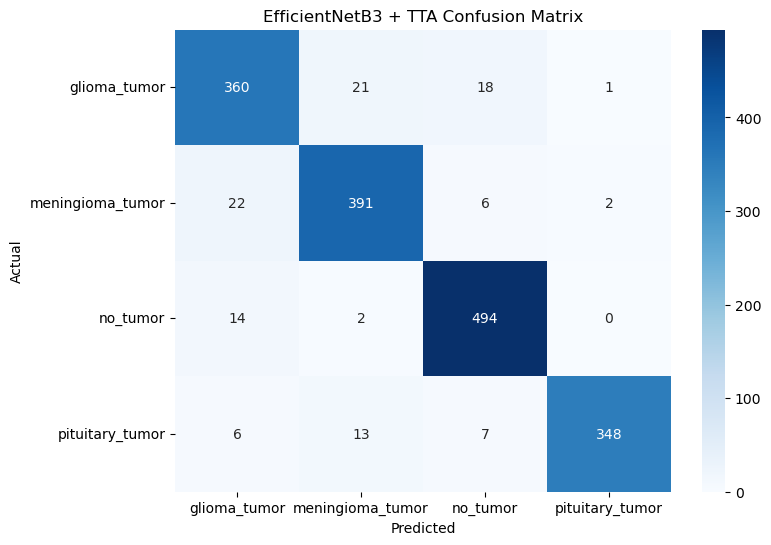

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EfficientNetB3 + TTA Confusion Matrix")
plt.show()